<a href="https://colab.research.google.com/github/tdtai09423/weather-forecast-group-project/blob/main/data_workspace/notebooks/01_EDA/Stage1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

Input Data

In [32]:
import os

# Auto-detect data path (Colab or local)
COLAB_PATH = '/content/sample_data/weather-forecast-data'
LOCAL_PATH  = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'data', 'raw'))
DATA_DIR = COLAB_PATH if os.path.exists(COLAB_PATH) else LOCAL_PATH

for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/Users/tranduytai/Documents/SUTD/DataVisualization/GroupProject/data_workspace/data/raw/.gitkeep
/Users/tranduytai/Documents/SUTD/DataVisualization/GroupProject/data_workspace/data/raw/changi.csv
/Users/tranduytai/Documents/SUTD/DataVisualization/GroupProject/data_workspace/data/raw/tuassouth.csv
/Users/tranduytai/Documents/SUTD/DataVisualization/GroupProject/data_workspace/data/raw/angmokio.csv


In [33]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    # Fix: removed num=None to avoid ValueError in newer matplotlib
    plt.figure(figsize=(6 * nGraphPerRow, 8 * nGraphRow), dpi=80, facecolor='w', edgecolor='k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation=90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show()

In [34]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = getattr(df, 'dataframeName', 'unknown')

    # Only keep numerical columns
    df = df.select_dtypes(include=[np.number])

    # Drop columns with NaN values
    df = df.dropna(axis='columns')

    # Keep columns with more than 1 unique value
    df = df[[col for col in df if df[col].nunique() > 1]]

    if df.shape[1] < 2:
        print(f'No correlation plots shown for {filename}: The number of valid numerical columns ({df.shape[1]}) is less than 2')
        return

    corr = df.corr()

    # Fill NaNs in correlation matrix if they exist
    if corr.isnull().values.any():
        corr = corr.fillna(0)

    # Fix: Create figure separately to avoid the truth value ambiguity error in matshow/figure logic
    plt.figure(figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    ax = plt.gca()
    corrMat = ax.matshow(corr, cmap='coolwarm')

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

In [35]:
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include=[np.number])
    df = df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique() > 1]]
    columnNames = list(df)
    if len(columnNames) > 10:
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    # Fix: plt.np was removed in matplotlib 3.7+, use np directly
    for i, j in zip(*np.triu_indices_from(ax, k=1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2),
                           xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

DF1

In [36]:
nRowsRead = 1000 # specify 'None' if want to read whole file
df1 = pd.read_csv(os.path.join(DATA_DIR, 'angmokio.csv'), delimiter=',', nrows=nRowsRead)
df1.dataframeName = 'angmokio.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')


There are 1000 rows and 14 columns


In [37]:
df1.head(5)

,Unnamed: 0,Station,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
0,0,Ang Mo Kio,2014,1,1,0.0,0.0,0.0,0.0,26.3,28.7,24.5,7.2,29.9
1,1,Ang Mo Kio,2014,1,2,0.0,0.0,0.0,0.0,26.9,30.4,24.6,8.2,32.0
2,2,Ang Mo Kio,2014,1,3,8.8,8.6,8.8,8.8,26.5,30.1,24.8,7.1,29.5
3,3,Ang Mo Kio,2014,1,4,1.4,1.4,1.4,1.4,26.6,30.9,24.7,4.2,30.2
4,4,Ang Mo Kio,2014,1,5,7.2,1.6,3.2,5.2,24.5,25.5,23.3,5.2,24.1


In [38]:
display(df1.describe())

,Unnamed: 0,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
count,1000.000000,1000.000000,1000.000000,1000.000000,999.000000,999.000000,999.000000,999.000000,993.000000,993.000000,993.000000,996.000000,995.000000
mean,499.500000,2014.905000,6.100000,15.672000,5.501702,3.635035,4.424424,4.883083,28.045217,32.066062,25.290131,6.089458,30.762111
std,288.819436,0.791582,3.307407,8.780861,11.586634,7.480825,9.390592,10.448013,1.222957,1.636198,1.455919,1.690452,6.893925
min,0.000000,2014.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,24.500000,25.500000,20.300000,3.000000,13.700000
25%,249.750000,2014.000000,3.000000,8.000000,0.000000,0.000000,0.000000,0.000000,27.200000,31.200000,24.200000,4.700000,26.300000
50%,499.500000,2015.000000,6.000000,16.000000,0.000000,0.000000,0.000000,0.000000,28.100000,32.300000,25.300000,5.800000,29.900000
75%,749.250000,2016.000000,9.000000,23.000000,5.000000,3.200000,3.600000,4.200000,29.000000,33.200000,26.300000,7.200000,34.600000
max,999.000000,2016.000000,12.000000,31.000000,88.600000,54.200000,67.800000,84.600000,31.100000,35.800000,28.600000,11.200000,73.800000


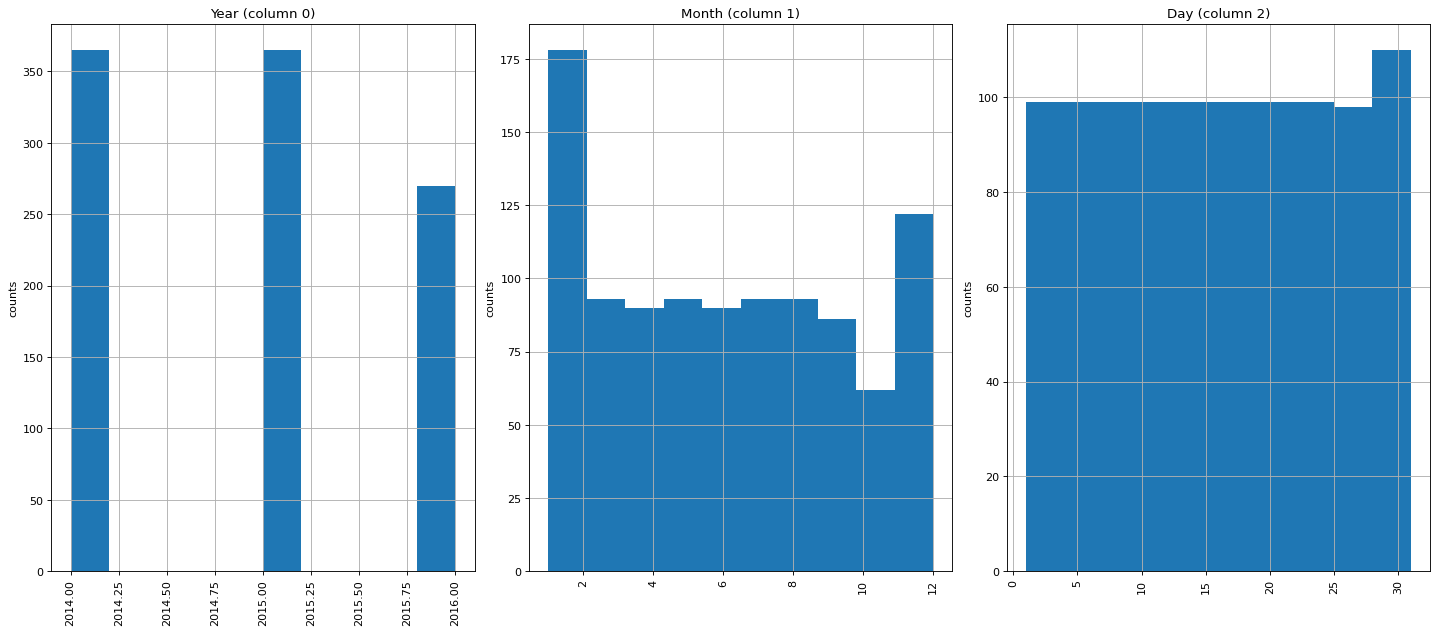

In [39]:
plotPerColumnDistribution(df1, 10, 5)

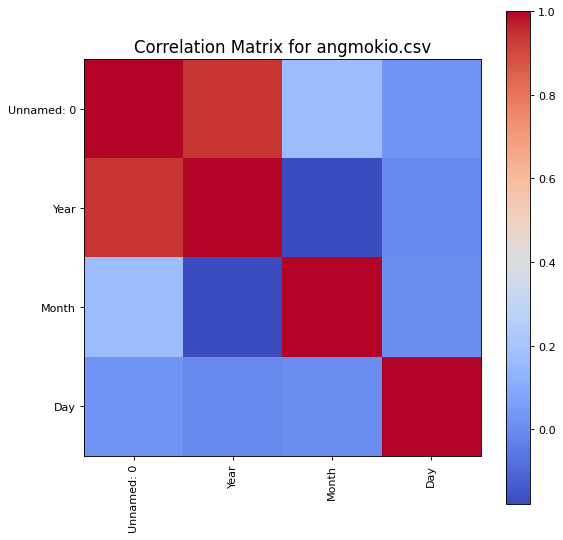

In [40]:
plotCorrelationMatrix(df1, 8)

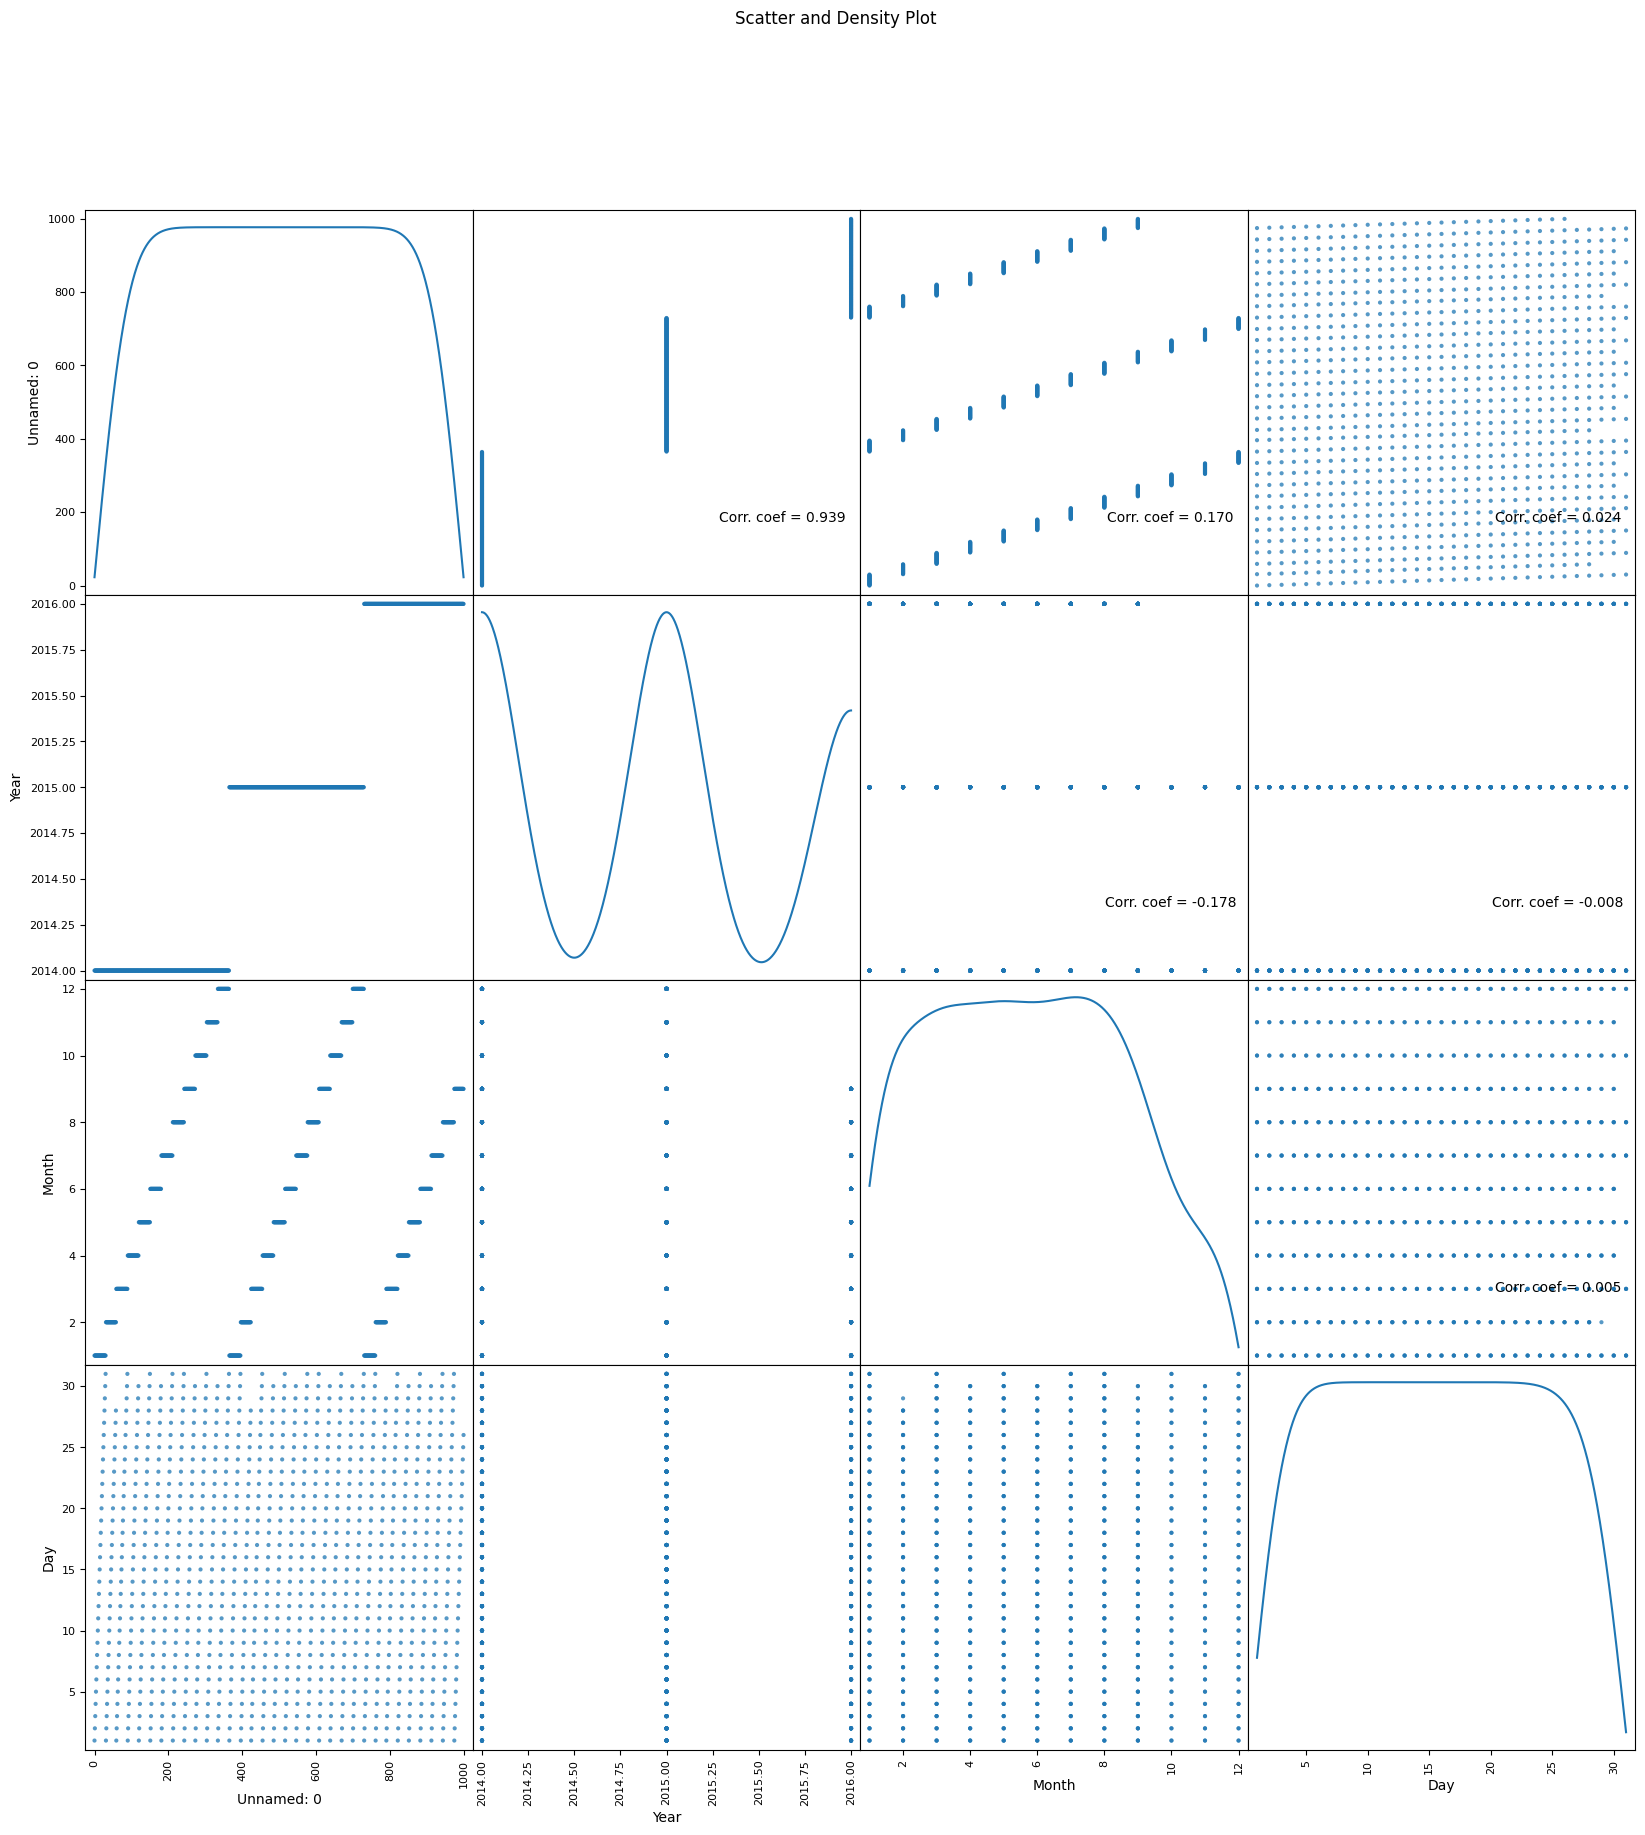

In [41]:
plotScatterMatrix(df1, 20, 10)

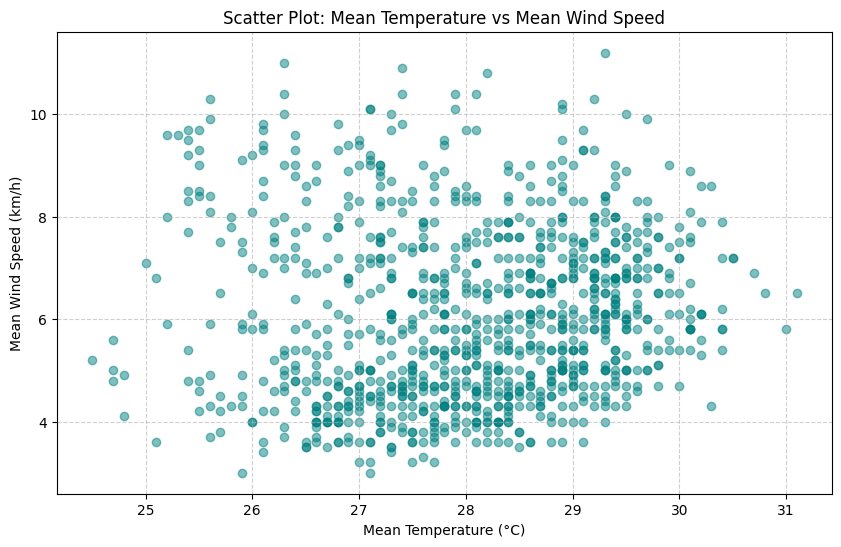

In [42]:
import matplotlib.pyplot as plt

# Create a scatter plot for Mean Temperature vs Mean Wind Speed
plt.figure(figsize=(10, 6))
plt.scatter(df1['Mean Temperature (°C)'], df1['Mean Wind Speed (km/h)'], alpha=0.5, color='teal')
plt.title('Scatter Plot: Mean Temperature vs Mean Wind Speed')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Mean Wind Speed (km/h)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

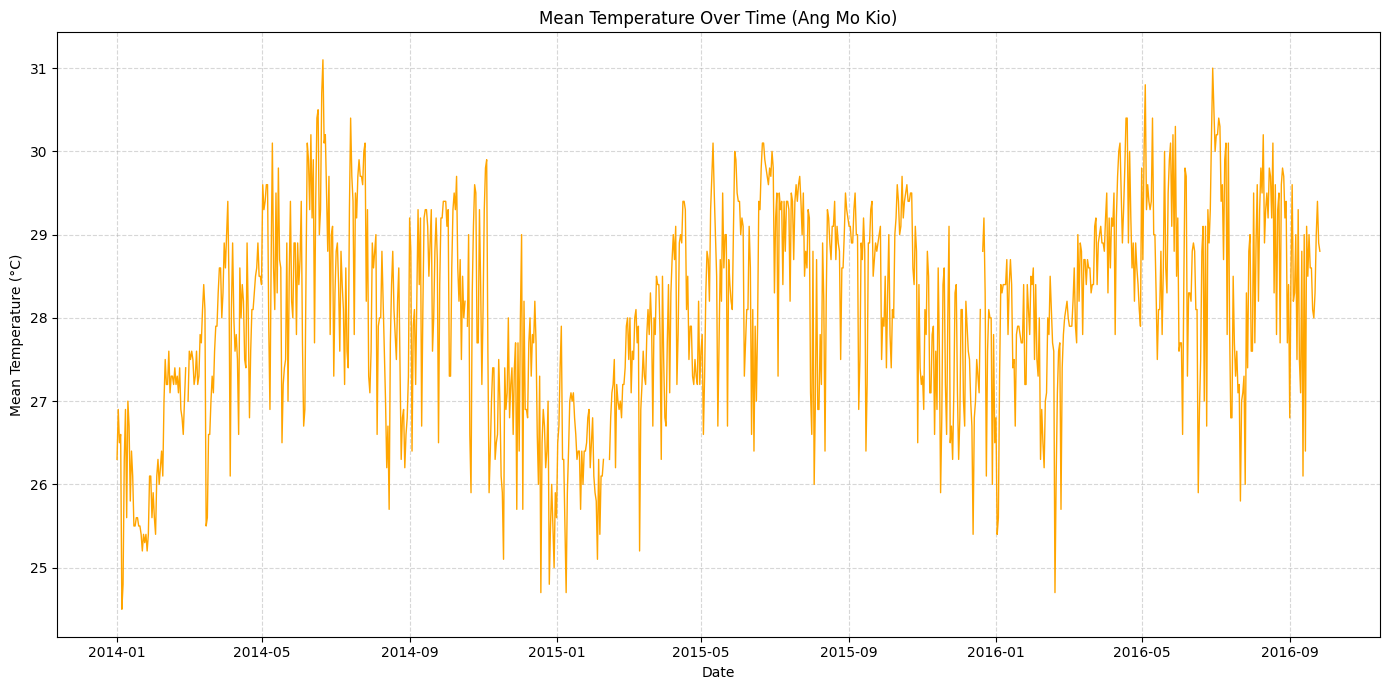

In [43]:
# Combine Year, Month, and Day into a single datetime column
df1['Date'] = pd.to_datetime(df1[['Year', 'Month', 'Day']])

# Plot Mean Temperature over time
plt.figure(figsize=(14, 7))
plt.plot(df1['Date'], df1['Mean Temperature (°C)'], color='orange', linewidth=1)
plt.title('Mean Temperature Over Time (Ang Mo Kio)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

DF2

In [44]:
nRowsRead = 1000 # specify 'None' if want to read whole file
df2 = pd.read_csv(os.path.join(DATA_DIR, 'changi.csv'), delimiter=',', nrows=nRowsRead)
df2.dataframeName = 'changi.csv'
nRow, nCol = df2.shape
print(f'There are {nRow} rows and {nCol} columns')


There are 1000 rows and 14 columns


In [45]:
df2.head(5)

,Unnamed: 0,Station,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),Maximum Temperature (°C),Minimum Temperature (°C),Mean Wind Speed (km/h),Max Wind Speed (km/h)
0,0,Changi,2014,1,1,0.0,0.0,0.0,0.0,26.7,29.0,24.9,10.0,29.9
1,1,Changi,2014,1,2,0.0,0.0,0.0,0.0,27.4,30.9,25.0,11.9,36.0
2,2,Changi,2014,1,3,0.0,0.0,0.0,0.0,27.1,30.4,24.9,9.7,33.1
3,3,Changi,2014,1,4,0.0,0.0,0.0,0.0,27.1,31.1,24.9,6.4,25.9
4,4,Changi,2014,1,5,18.4,8.6,10.8,15.4,24.8,26.4,23.3,6.8,25.6


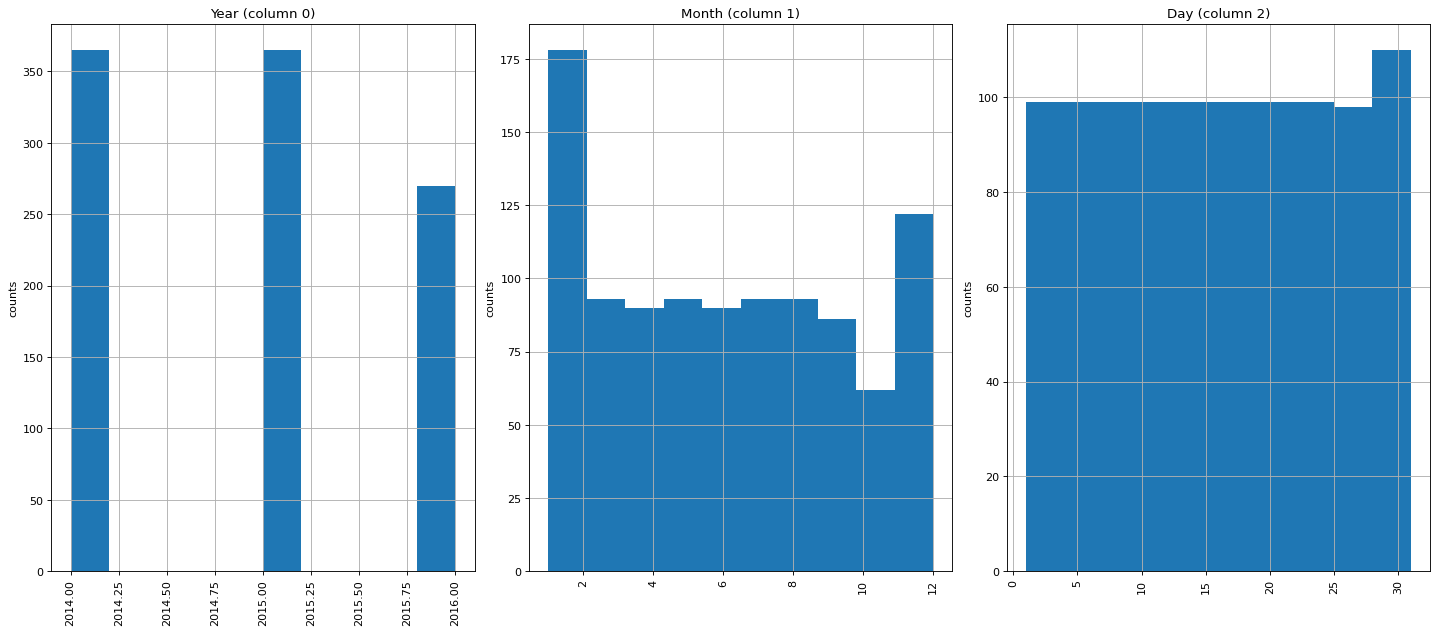

In [46]:
plotPerColumnDistribution(df2, 10, 5)

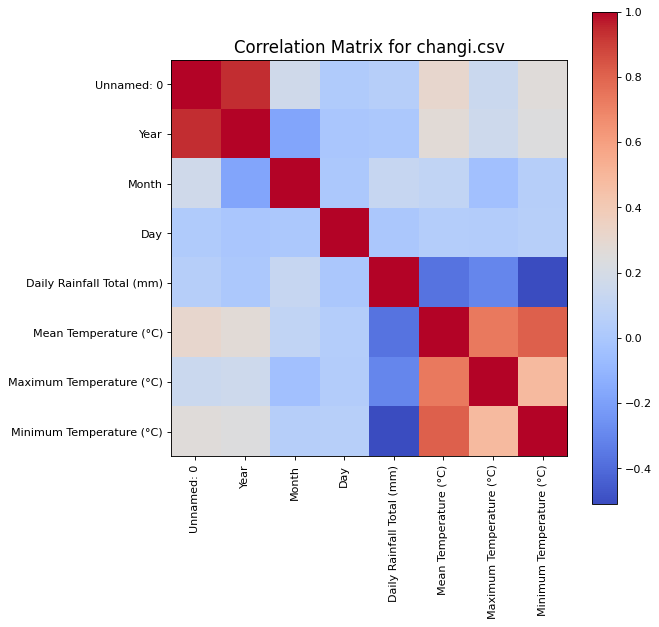

In [47]:
plotCorrelationMatrix(df2, 8)

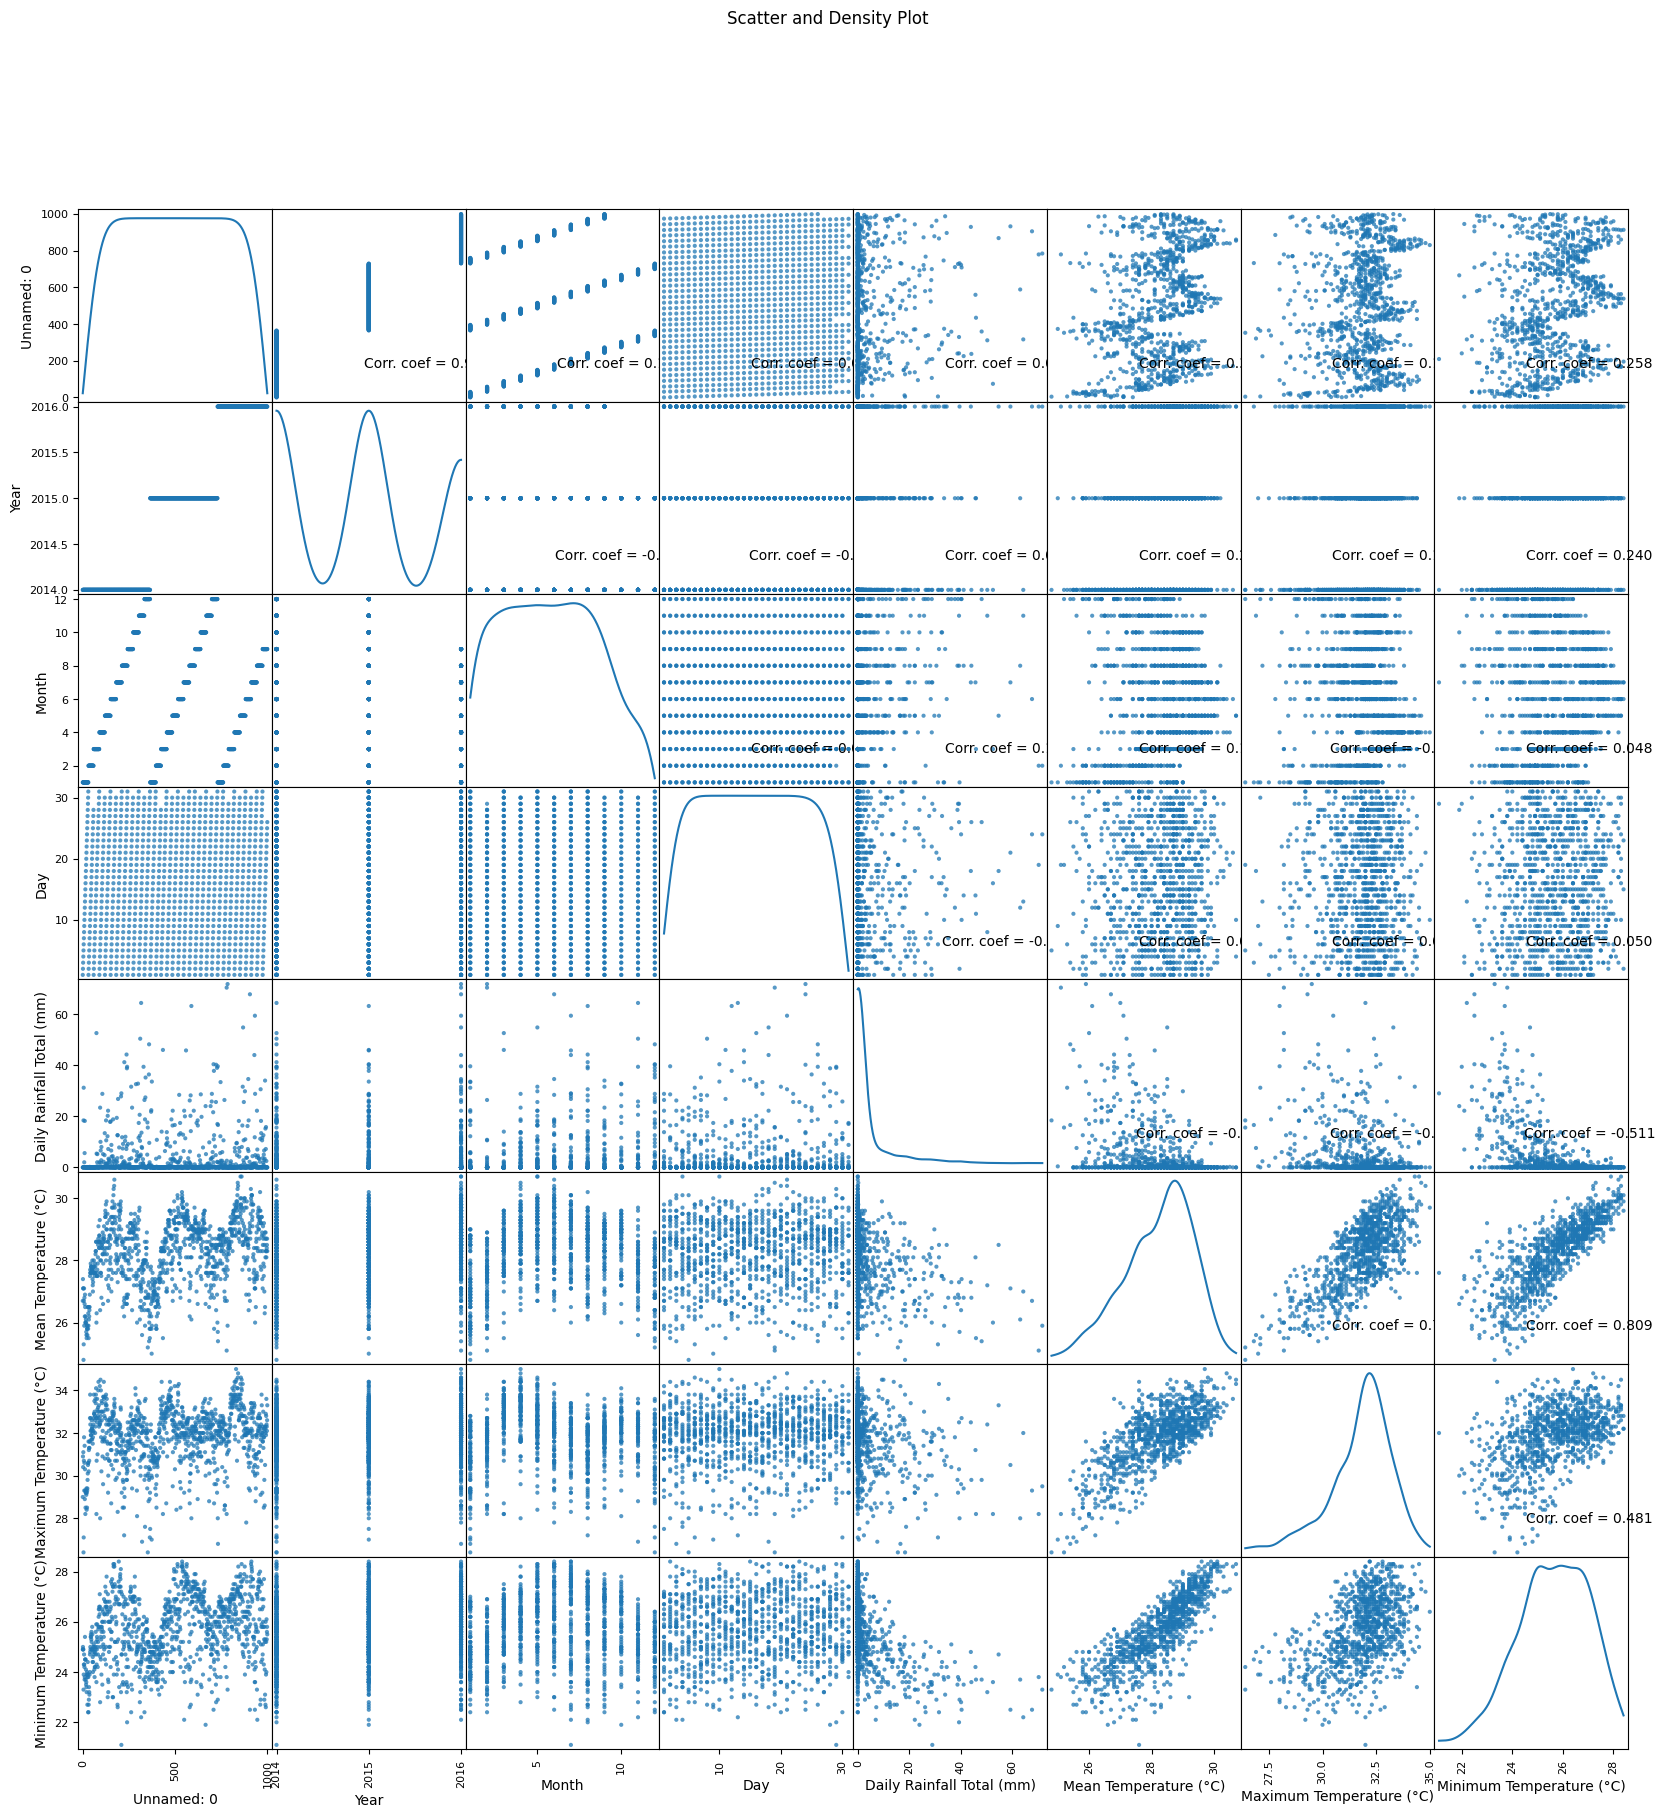

In [48]:
plotScatterMatrix(df2, 20, 10)

Model Performance for changi.csv:
Mean Absolute Error: 0.50 °C
R^2 Score: 0.58


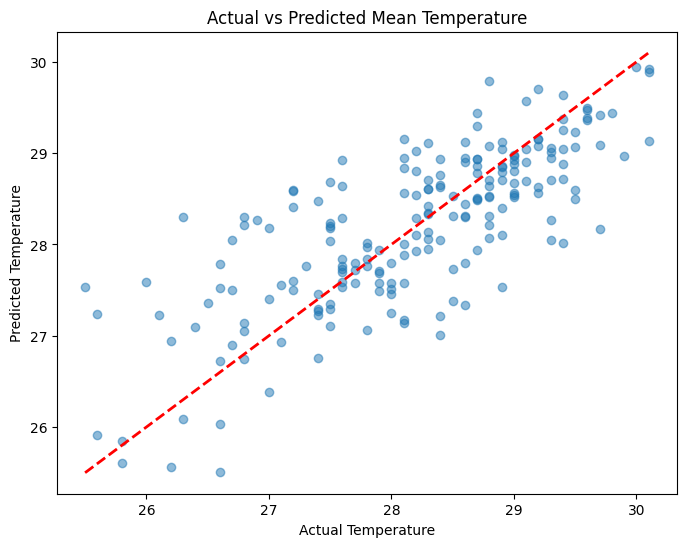

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare the data
# We'll use Year, Month, Day, and Rainfall to predict Mean Temperature
features = ['Year', 'Month', 'Day', 'Daily Rainfall Total (mm)']
target = 'Mean Temperature (°C)'

# Drop rows with missing values in our selected columns
ml_df = df2[features + [target]].dropna()

X = ml_df[features]
y = ml_df[target]

# 2. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions and evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'Model Performance for {df2.dataframeName}:')
print(f'Mean Absolute Error: {mae:.2f} °C')
print(f'R^2 Score: {r2:.2f}')

# 5. Visualize actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Mean Temperature')
plt.show()

Comparison for changi.csv:
--- Random Forest ---
MAE: 0.4972, R2: 0.5779
--- Linear Regression ---
MAE: 0.7378, R2: 0.1623


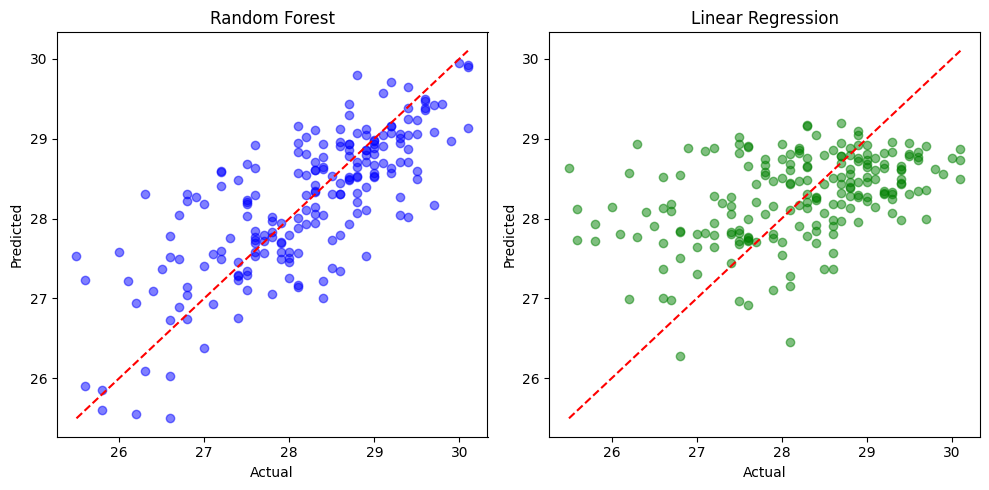

In [50]:
from sklearn.linear_model import LinearRegression

# 1. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Make predictions and evaluate
lr_predictions = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print(f'Comparison for {df2.dataframeName}:')
print(f'--- Random Forest ---')
print(f'MAE: {mae:.4f}, R2: {r2:.4f}')
print(f'--- Linear Regression ---')
print(f'MAE: {lr_mae:.4f}, R2: {lr_r2:.4f}')

# 3. Visualize Comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test, lr_predictions, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

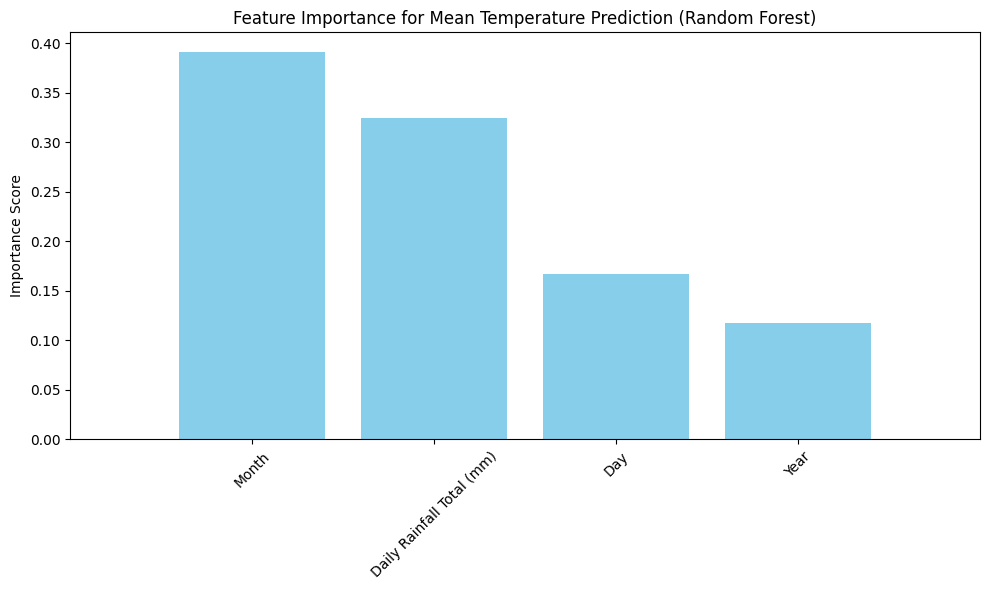

1. feature Month (0.3914)
2. feature Daily Rainfall Total (mm) (0.3241)
3. feature Day (0.1669)
4. feature Year (0.1175)


In [51]:
# Calculate feature importance from the Random Forest model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = [features[i] for i in indices]

# Create the plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Mean Temperature Prediction (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], color="skyblue", align="center")
plt.xticks(range(X.shape[1]), feature_names, rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Print the importance values
for f in range(X.shape[1]):
    print(f"{f + 1}. feature {feature_names[f]} ({importances[indices[f]]:.4f})")

# 🤖 ML Pipeline — Weather Temperature Forecasting

Sau khi EDA, chúng ta đi qua các bước:

| Bước | Tên | Mô tả |
|------|-----|--------|
| 1 | Load & Merge | Gộp dữ liệu từ nhiều trạm, xử lý missing values |
| 2 | Feature Engineering | Tạo feature mới: cyclical encoding, lag, rolling stats |
| 3 | Preprocessing Pipeline | Scale features chuẩn bị cho model |
| 4 | Train nhiều model | So sánh Linear, RandomForest, GradientBoosting |
| 5 | Evaluate nghiêm túc | Cross-validation, RMSE/MAE/R², residual plot |
| 6 | Hyperparameter Tuning | RandomizedSearchCV cho best model |
| 7 | Save model | Lưu `.pkl` + export `.onnx` cho production |

## Bước 1 — Load & Merge Data từ nhiều trạm

In [52]:
import os
import pandas as pd
import numpy as np

# ── Tự động phát hiện đường dẫn data (Colab hoặc local) ──────────────────────
COLAB_PATH = '/content/sample_data/weather-forecast-data'
LOCAL_PATH  = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                           '..', '..', 'data', 'raw')

DATA_DIR = COLAB_PATH if os.path.exists(COLAB_PATH) else LOCAL_PATH
print(f'📂 Data directory: {DATA_DIR}')

# ── Load từng trạm ────────────────────────────────────────────────────────────
station_files = {
    'angmokio': os.path.join(DATA_DIR, 'angmokio.csv'),
    'changi'  : os.path.join(DATA_DIR, 'changi.csv'),
}

dfs = []
for station, path in station_files.items():
    if os.path.exists(path):
        tmp = pd.read_csv(path)
        tmp['Station'] = station          # thêm cột nhận biết trạm
        dfs.append(tmp)
        print(f'  ✅ Loaded {station}: {tmp.shape}')
    else:
        print(f'  ⚠️  File not found: {path}')

df_all = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f'\n📊 Combined shape: {df_all.shape}')
print(df_all.head(3))

📂 Data directory: /Users/tranduytai/Documents/SUTD/DataVisualization/GroupProject/data_workspace/notebooks/01_EDA/../../data/raw
  ✅ Loaded angmokio: (2557, 14)
  ✅ Loaded changi: (2557, 14)

📊 Combined shape: (5114, 14)
   Unnamed: 0   Station  Year  Month  Day  Daily Rainfall Total (mm)  \
0           0  angmokio  2014      1    1                        0.0   
1           1  angmokio  2014      1    2                        0.0   
2           2  angmokio  2014      1    3                        8.8   

   Highest 30 min Rainfall (mm)  Highest 60 min Rainfall (mm)  \
0                           0.0                           0.0   
1                           0.0                           0.0   
2                           8.6                           8.8   

   Highest 120 min Rainfall (mm)  Mean Temperature (°C)  \
0                            0.0                   26.3   
1                            0.0                   26.9   
2                            8.8                   2

In [53]:
# ── Xử lý missing values ──────────────────────────────────────────────────────
print("Missing values trước khi xử lý:")
print(df_all.isnull().sum()[df_all.isnull().sum() > 0])

# Với cột số: điền bằng median (robust hơn mean khi có outlier)
num_cols = df_all.select_dtypes(include=np.number).columns.tolist()
df_all[num_cols] = df_all[num_cols].fillna(df_all[num_cols].median())

# Xoá hàng vẫn còn NaN (nếu có cột khác)
df_all = df_all.dropna()

print(f"\n✅ Missing values sau khi xử lý: {df_all.isnull().sum().sum()}")
print(f"📊 Shape sau xử lý: {df_all.shape}")

Missing values trước khi xử lý:
Daily Rainfall Total (mm)        45
Highest 30 min Rainfall (mm)     54
Highest 60 min Rainfall (mm)     58
Highest 120 min Rainfall (mm)    58
Mean Temperature (°C)            48
Maximum Temperature (°C)         48
Minimum Temperature (°C)         48
Mean Wind Speed (km/h)           50
Max Wind Speed (km/h)            57
dtype: int64

✅ Missing values sau khi xử lý: 0
📊 Shape sau xử lý: (5114, 14)


## Bước 2 — Feature Engineering

> **Tại sao cần Feature Engineering?**  
> Model ML chỉ nhận số. Chúng ta cần biến đổi các cột raw (Year/Month/Day, các chỉ số thời tiết) thành dạng mà model có thể học hiệu quả.
>
> Các kỹ thuật sẽ dùng:
> - **Cyclical Encoding** (sin/cos) cho Month, Day — vì tháng 12 gần tháng 1 hơn tháng 6
> - **Lag Features** — nhiệt độ hôm qua, 3 ngày trước (time-series pattern)
> - **Rolling Statistics** — trung bình 7 ngày (smoothing trend)

In [54]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── 1. Tạo cột Date ────────────────────────────────────────────────────────
    df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    df = df.sort_values(['Station', 'Date']).reset_index(drop=True)

    # ── 2. Cyclical Encoding cho Month và Day ─────────────────────────────────
    # Biến month/day thành sin/cos để model hiểu "tháng 12 gần tháng 1"
    df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    df['Day_sin']   = np.sin(2 * np.pi * df['Day'] / 31)
    df['Day_cos']   = np.cos(2 * np.pi * df['Day'] / 31)

    # ── 3. Lag Features (per station) ─────────────────────────────────────────
    # "Nhiệt độ hôm qua/3 ngày trước" là predictor rất mạnh cho hôm nay
    target_col = 'Mean Temperature (°C)'
    if target_col in df.columns:
        for lag in [1, 3, 7]:
            df[f'Temp_lag_{lag}d'] = df.groupby('Station')[target_col].shift(lag)

        # ── 4. Rolling Statistics (7-day window) ──────────────────────────────
        df['Temp_rolling_mean_7d'] = (
            df.groupby('Station')[target_col]
              .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
        )
        df['Temp_rolling_std_7d'] = (
            df.groupby('Station')[target_col]
              .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std().fillna(0))
        )

    # ── 5. Rainfall lag ───────────────────────────────────────────────────────
    rain_col = 'Daily Rainfall Total (mm)'
    if rain_col in df.columns:
        df['Rain_lag_1d'] = df.groupby('Station')[rain_col].shift(1)

    return df


df_feat = engineer_features(df_all)

# Xoá hàng NaN sinh ra bởi lag (vài ngày đầu mỗi station)
df_feat = df_feat.dropna()

print(f"✅ Features sau engineering: {df_feat.shape[1]} cột, {df_feat.shape[0]} hàng")
print("\nDanh sách features mới:")
new_cols = [c for c in df_feat.columns if c not in df_all.columns or c == 'Date']
print(new_cols)
df_feat.head(3)

✅ Features sau engineering: 25 cột, 5100 hàng

Danh sách features mới:
['Date', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Temp_lag_1d', 'Temp_lag_3d', 'Temp_lag_7d', 'Temp_rolling_mean_7d', 'Temp_rolling_std_7d', 'Rain_lag_1d']


,Unnamed: 0,Station,Year,Month,Day,Daily Rainfall Total (mm),Highest 30 min Rainfall (mm),Highest 60 min Rainfall (mm),Highest 120 min Rainfall (mm),Mean Temperature (°C),...,Month_sin,Month_cos,Day_sin,Day_cos,Temp_lag_1d,Temp_lag_3d,Temp_lag_7d,Temp_rolling_mean_7d,Temp_rolling_std_7d,Rain_lag_1d
7,7,angmokio,2014,1,8,0.0,0.0,0.0,0.0,26.9,...,0.5,0.866025,0.998717,-0.050649,26.3,24.5,26.3,25.985714,0.938844,2.0
8,8,angmokio,2014,1,9,6.4,3.8,5.0,5.8,25.6,...,0.5,0.866025,0.968077,-0.250653,26.9,24.8,26.9,26.071429,0.997855,0.0
9,9,angmokio,2014,1,10,0.0,0.0,0.0,0.0,27.0,...,0.5,0.866025,0.897805,-0.440394,25.6,26.3,26.5,25.885714,0.937067,6.4


## Bước 3 — Chuẩn bị tập Train/Test & Preprocessing Pipeline

In [55]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Chọn features và target ───────────────────────────────────────────────────
TARGET = 'Mean Temperature (°C)'

FEATURE_COLS = [
    # Time cyclical
    'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Year',
    # Weather raw
    'Daily Rainfall Total (mm)',
    'Mean Wind Speed (km/h)',
    # Lag / rolling (time-series patterns)
    'Temp_lag_1d', 'Temp_lag_3d', 'Temp_lag_7d',
    'Temp_rolling_mean_7d', 'Temp_rolling_std_7d',
    'Rain_lag_1d',
]

# Chỉ giữ các cột tồn tại trong df
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]
print(f"📌 Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

# ── Train/Test split — dùng time-based split (không shuffle) ─────────────────
# Với time-series: không nên shuffle ngẫu nhiên vì sẽ "rò rỉ tương lai"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # giữ thứ tự thời gian
)

print(f"\n📊 Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ── Preprocessing Pipeline ────────────────────────────────────────────────────
# Imputer: fill NaN (nếu còn sót) → Scaler: chuẩn hoá về mean=0, std=1
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

📌 Feature columns (13): ['Month_sin', 'Month_cos', 'Day_sin', 'Day_cos', 'Year', 'Daily Rainfall Total (mm)', 'Mean Wind Speed (km/h)', 'Temp_lag_1d', 'Temp_lag_3d', 'Temp_lag_7d', 'Temp_rolling_mean_7d', 'Temp_rolling_std_7d', 'Rain_lag_1d']

📊 Train: 4080 samples | Test: 1020 samples


## Bước 4 — Train & So sánh nhiều Model

In [56]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Định nghĩa các model sẽ so sánh ──────────────────────────────────────────
MODELS = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# ── Train từng model trong Pipeline (Preprocessor + Model) ───────────────────
results = {}
trained_pipelines = {}

for name, model in MODELS.items():
    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', model),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    trained_pipelines[name] = pipe
    print(f"✅ {name:22s} → MAE: {mae:.3f}°C | RMSE: {rmse:.3f}°C | R²: {r2:.4f}")

# ── Hiển thị bảng so sánh ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print("\n📊 Bảng so sánh (sắp xếp theo RMSE tăng dần):")
display(results_df.style.highlight_min(color='lightgreen', axis=0)
                        .format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'R²': '{:.4f}'}))

✅ Linear Regression      → MAE: 0.493°C | RMSE: 0.646°C | R²: 0.6134
✅ Ridge Regression       → MAE: 0.493°C | RMSE: 0.646°C | R²: 0.6134
✅ Random Forest          → MAE: 0.406°C | RMSE: 0.540°C | R²: 0.7304
✅ Gradient Boosting      → MAE: 0.411°C | RMSE: 0.537°C | R²: 0.7332

📊 Bảng so sánh (sắp xếp theo RMSE tăng dần):


,MAE,RMSE,R²
Gradient Boosting,0.411,0.537,0.7332
Random Forest,0.406,0.540,0.7304
Ridge Regression,0.493,0.646,0.6134
Linear Regression,0.493,0.646,0.6134


## Bước 5 — Đánh giá Chi tiết (Cross-Validation + Visualization)

In [57]:
from sklearn.model_selection import KFold

# ── 5a. Cross-Validation (5-fold) cho tất cả models ──────────────────────────
print("📊 5-Fold Cross-Validation (trên tập train):\n")
cv = KFold(n_splits=5, shuffle=False)  # shuffle=False giữ thứ tự thời gian

cv_results = {}
for name, model in MODELS.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    cv_scores = cross_validate(pipe, X_train, y_train, cv=cv,
                                scoring=['neg_mean_absolute_error',
                                         'neg_root_mean_squared_error', 'r2'],
                                n_jobs=-1)
    cv_results[name] = {
        'CV MAE (mean)'  : -cv_scores['test_neg_mean_absolute_error'].mean(),
        'CV MAE (std)'   :  cv_scores['test_neg_mean_absolute_error'].std(),
        'CV RMSE (mean)' : -cv_scores['test_neg_root_mean_squared_error'].mean(),
        'CV R² (mean)'   :  cv_scores['test_r2'].mean(),
    }

cv_df = pd.DataFrame(cv_results).T.sort_values('CV RMSE (mean)')
display(cv_df.style.highlight_min(color='lightgreen', axis=0)
              .format({col: '{:.3f}' for col in cv_df.columns}))

📊 5-Fold Cross-Validation (trên tập train):



,CV MAE (mean),CV MAE (std),CV RMSE (mean),CV R² (mean)
Random Forest,0.459,0.042,0.596,0.735
Gradient Boosting,0.478,0.049,0.613,0.720
Ridge Regression,0.535,0.054,0.699,0.637
Linear Regression,0.535,0.054,0.699,0.637


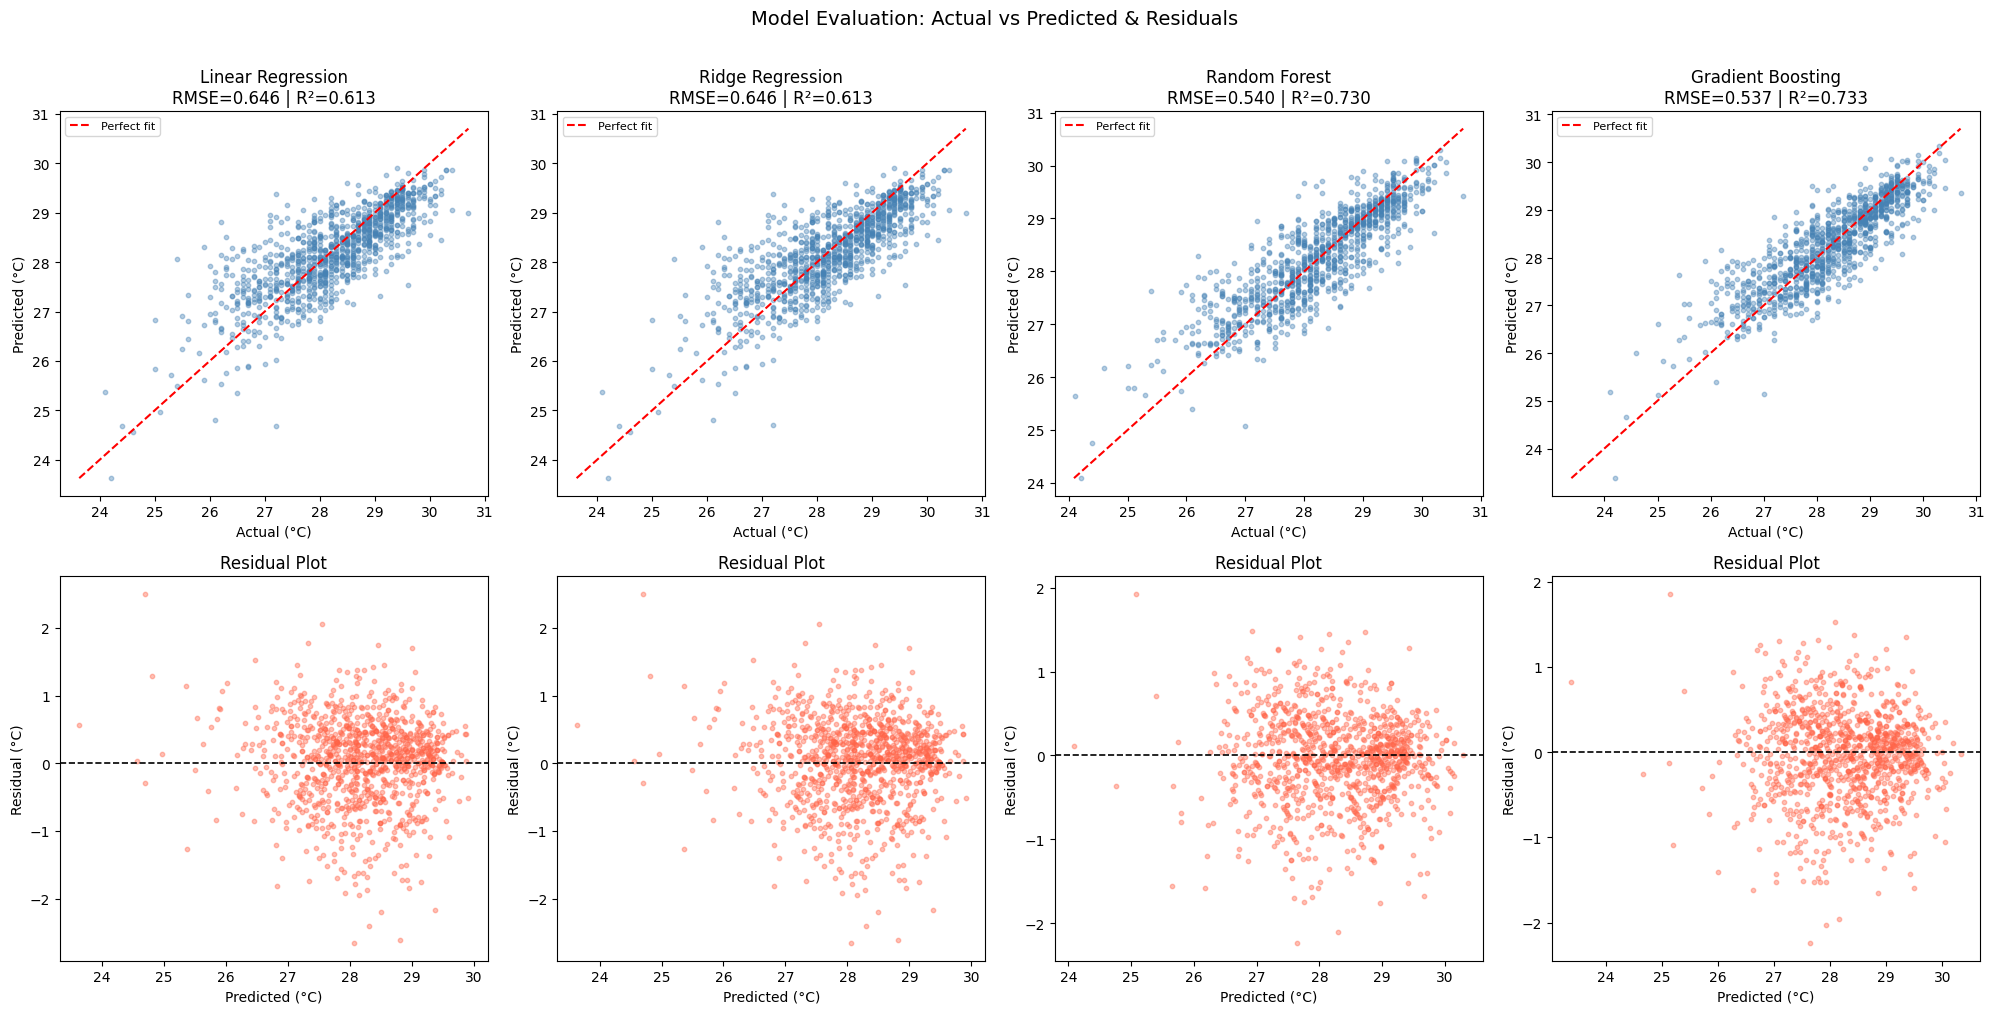

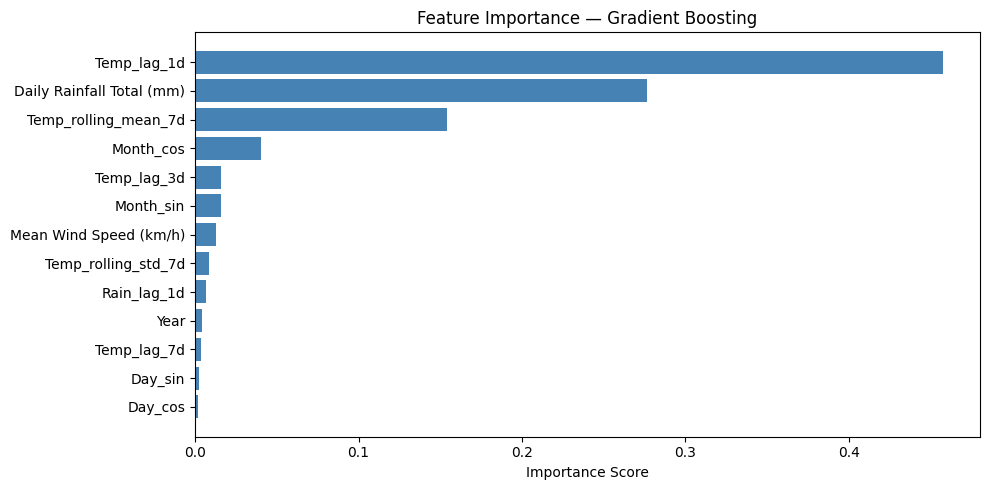

,Feature,Importance
7,Temp_lag_1d,0.457354
5,Daily Rainfall Total (mm),0.276759
10,Temp_rolling_mean_7d,0.153903
1,Month_cos,0.040373
8,Temp_lag_3d,0.015941
0,Month_sin,0.015561
6,Mean Wind Speed (km/h),0.013017
11,Temp_rolling_std_7d,0.008281
12,Rain_lag_1d,0.006734
4,Year,0.004336


In [58]:
# ── 5b. Visualization: Actual vs Predicted + Residual Plot ───────────────────
fig, axes = plt.subplots(2, len(MODELS), figsize=(5 * len(MODELS), 10))
fig.suptitle('Model Evaluation: Actual vs Predicted & Residuals', fontsize=14, y=1.01)

for col, (name, pipe) in enumerate(trained_pipelines.items()):
    preds = pipe.predict(X_test)
    residuals = y_test.values - preds

    # ── Row 0: Actual vs Predicted ────────────────────────────────────────────
    ax0 = axes[0, col]
    ax0.scatter(y_test, preds, alpha=0.4, s=10, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax0.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax0.set_xlabel('Actual (°C)')
    ax0.set_ylabel('Predicted (°C)')
    ax0.set_title(f'{name}\nRMSE={results[name]["RMSE"]:.3f} | R²={results[name]["R²"]:.3f}')
    ax0.legend(fontsize=8)

    # ── Row 1: Residual Plot (residuals vs predicted) ─────────────────────────
    ax1 = axes[1, col]
    ax1.scatter(preds, residuals, alpha=0.4, s=10, color='tomato')
    ax1.axhline(0, color='black', lw=1.2, linestyle='--')
    ax1.set_xlabel('Predicted (°C)')
    ax1.set_ylabel('Residual (°C)')
    ax1.set_title('Residual Plot')

plt.tight_layout()
plt.show()

# ── 5c. Feature Importance (cho best tree-based model) ───────────────────────
BEST_TREE = 'Gradient Boosting'
best_pipe  = trained_pipelines[BEST_TREE]
importances = best_pipe.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances,
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title(f'Feature Importance — {BEST_TREE}')
plt.tight_layout()
plt.show()
display(feat_imp_df)

## Bước 6 — Hyperparameter Tuning (RandomizedSearchCV)

In [59]:
from sklearn.model_selection import RandomizedSearchCV

# ── Tune Gradient Boosting (thường là best model cho tabular data) ────────────
param_dist = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [3, 4, 5, 6],
    'model__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample'       : [0.7, 0.8, 1.0],
}

tuning_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(random_state=42)),
])

search = RandomizedSearchCV(
    tuning_pipe,
    param_dist,
    n_iter=30,                     # thử 30 tổ hợp ngẫu nhiên
    scoring='neg_root_mean_squared_error',
    cv=KFold(n_splits=5, shuffle=False),
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("🔍 Đang tìm hyperparameters tốt nhất...")
search.fit(X_train, y_train)

print(f"\n✅ Best params: {search.best_params_}")
print(f"   Best CV RMSE: {-search.best_score_:.3f}°C")

best_model = search.best_estimator_
test_preds  = best_model.predict(X_test)
print(f"\n📊 Test set sau tuning:")
print(f"   MAE  = {mean_absolute_error(y_test, test_preds):.3f}°C")
print(f"   RMSE = {np.sqrt(mean_squared_error(y_test, test_preds)):.3f}°C")
print(f"   R²   = {r2_score(y_test, test_preds):.4f}")

🔍 Đang tìm hyperparameters tốt nhất...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_samples_leaf': 4, 'model__max_depth': 5, 'model__learning_rate': 0.05}
   Best CV RMSE: 0.597°C

📊 Test set sau tuning:
   MAE  = 0.403°C
   RMSE = 0.529°C
   R²   = 0.7405


## Bước 7 — Save Model (.pkl & .onnx)

Lưu model để dùng trong `ml_service/` (FastAPI sẽ load file này để serve predictions).

In [60]:
import joblib, json, os

# ── Đường dẫn lưu model ───────────────────────────────────────────────────────
MODELS_DIR = os.path.join('..', '..', 'models')   # data_workspace/models/
os.makedirs(MODELS_DIR, exist_ok=True)

# ── 7a. Lưu sklearn Pipeline (.pkl) ──────────────────────────────────────────
pkl_path = os.path.join(MODELS_DIR, 'weather_temp_model.pkl')
joblib.dump(best_model, pkl_path)
print(f"✅ Saved sklearn pipeline → {pkl_path}")

# ── 7b. Lưu metadata (feature list, metrics) ──────────────────────────────────
meta = {
    'feature_cols': FEATURE_COLS,
    'target'      : TARGET,
    'model_type'  : 'GradientBoostingRegressor',
    'best_params' : search.best_params_,
    'test_metrics': {
        'MAE' : round(mean_absolute_error(y_test, test_preds), 4),
        'RMSE': round(float(np.sqrt(mean_squared_error(y_test, test_preds))), 4),
        'R2'  : round(r2_score(y_test, test_preds), 4),
    }
}
meta_path = os.path.join(MODELS_DIR, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✅ Saved metadata       → {meta_path}")

# ── 7c. Export sang ONNX (để dùng trong ml_service với onnxruntime) ───────────
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType

    n_features = len(FEATURE_COLS)
    initial_type = [('float_input', FloatTensorType([None, n_features]))]
    onnx_model   = convert_sklearn(best_model, initial_types=initial_type)

    onnx_path = os.path.join(MODELS_DIR, 'weather_temp_model.onnx')
    with open(onnx_path, 'wb') as f:
        f.write(onnx_model.SerializeToString())
    print(f"✅ Saved ONNX model     → {onnx_path}")
except ImportError:
    print("⚠️  skl2onnx chưa cài — chạy: pip install skl2onnx  để export ONNX")
except Exception as e:
    print(f"⚠️  Không export được ONNX: {e}")

print("\n📦 Files trong models/:")
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
    print(f"   {f:40s} {size:.1f} KB")

✅ Saved sklearn pipeline → ../../models/weather_temp_model.pkl
✅ Saved metadata       → ../../models/model_metadata.json
✅ Saved ONNX model     → ../../models/weather_temp_model.onnx

📦 Files trong models/:
   model_metadata.json                      0.6 KB
   weather_temp_model.pkl                   439.0 KB
   .gitkeep                                 0.0 KB
   weather_temp_model.onnx                  204.7 KB


## ✅ Tổng kết ML Pipeline

| Bước | Kết quả |
|------|---------|
| Feature Engineering | Cyclical encoding, lag 1/3/7d, rolling 7d mean/std |
| Best Model | Gradient Boosting (tuned by RandomizedSearchCV) |
| Metrics | Xem `model_metadata.json` |
| Output files | `models/weather_temp_model.pkl` ← dùng cho `ml_service/` |
| | `models/weather_temp_model.onnx` ← production inference |
| | `models/model_metadata.json` ← feature list + metrics |

### Load lại model để predict sau này:
```python
import joblib, json
import numpy as np

model = joblib.load('../../models/weather_temp_model.pkl')
meta  = json.load(open('../../models/model_metadata.json'))

# Tạo một sample input (đúng thứ tự feature)
sample = np.array([[0.5, 0.866, 0.2, 0.98, 2024,
                    5.0, 10.0, 28.5, 28.2, 28.0, 28.3, 0.3, 3.0]])
pred = model.predict(sample)
print(f'Predicted temperature: {pred[0]:.2f}°C')
```